# consumer-agents — Cross-Run Comparison

Two layers of analysis side-by-side across 1–3 runs:

- **Per-persona narratives** — what each persona actually did (N1–N4)
- **Cross-run statistical comparison** — entrenchment, divergence, exploration (B, C, E)

All SKU references show **catalog names** (e.g., *Coffee Shop Drip Coffee*) not internal IDs.

Set the run paths below and run all cells. Any run set to `None` is skipped.


## 1. Setup


In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from consumer_agents.datalake.queries import open_run
from consumer_agents.world.catalog import load_catalog

RUN_BASELINE     = Path("../runs/baseline-d862c721")
RUN_NO_REFL      = Path("../runs/baseline_no_reflections-72d5b0bb")
RUN_FIRST_PERSON = Path("../runs/baseline_first_person-8ec49f4d")

_RUNS = {
    "baseline":     RUN_BASELINE,
    "no_refl":      RUN_NO_REFL,
    "first_person": RUN_FIRST_PERSON,
}
RUNS = {k: v for k, v in _RUNS.items() if v is not None}
CONS = {label: open_run(p) for label, p in RUNS.items()}

# Load catalog so we can map sku_id -> human-readable name
_catalog = load_catalog("../world")
SKU_NAME = {sku.id: sku.name for sku in _catalog.skus}

def sku_label(sku_id):
    """Pretty name for a SKU id, with the id appended for traceability."""
    return SKU_NAME.get(sku_id, sku_id)

def add_sku_name(df, col="sku_id"):
    if col in df.columns:
        df = df.copy()
        df.insert(df.columns.get_loc(col) + 1, "sku_name",
                  df[col].map(lambda s: SKU_NAME.get(s, s)))
    return df

def q_all(sql):
    frames = []
    for label, con in CONS.items():
        df = con.execute(sql).fetchdf()
        df.insert(0, "run", label)
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

SHORT = {
    "persona-maya-001":  "Maya",
    "persona-raj-001":   "Raj",
    "persona-elena-001": "Elena",
}
AGENTS = sorted(SHORT.keys())

print(f"Loaded {len(CONS)} runs and {len(SKU_NAME)} SKUs:")
for label, p in RUNS.items():
    print(f"  {label:14}  →  {p}")


Loaded 3 runs and 55 SKUs:
  baseline        →  ../runs/baseline-d862c721
  no_refl         →  ../runs/baseline_no_reflections-72d5b0bb
  first_person    →  ../runs/baseline_first_person-8ec49f4d


## 2. Top-line event counts


In [2]:
counts = q_all("SELECT event_type, COUNT(*) AS n FROM events GROUP BY 1")
counts.pivot_table(index="event_type", columns="run", values="n",
                   aggfunc="sum", fill_value=0)


run,baseline,first_person,no_refl
event_type,,,
abandon,1,25,1
cart_add,333,336,578
expense,9,9,9
income,18,18,18
purchase,263,183,262
reflection,39,39,0
view,265,342,543


## 3. Per-persona narrative arc

Auto-generated prose summary per (persona × run). Deterministic — built from SQL queries, no LLM. SKU references use catalog names.


In [4]:
def _query_one(con, sql, default=None):
    row = con.execute(sql).fetchone()
    if row is None or row[0] is None:
        return default
    return row[0]

def narrative_arc(con, agent_id: str, n_ticks_guess: int = 90) -> str:
    name = SHORT.get(agent_id, agent_id)
    n_purch = _query_one(con, f"SELECT COUNT(*) FROM v_purchases WHERE agent_id='{agent_id}'", 0)
    if n_purch == 0:
        return f"{name}: no purchases recorded in this run."

    total_spend = _query_one(con, f"SELECT ROUND(SUM(total_usd), 2) FROM v_purchases WHERE agent_id='{agent_id}'", 0)
    cash_start = _query_one(con, f"""
      SELECT cash_usd FROM snapshots WHERE agent_id='{agent_id}' AND kind='daily_econ' ORDER BY tick_day LIMIT 1
    """, 0)
    cash_end = _query_one(con, f"""
      SELECT cash_usd FROM snapshots WHERE agent_id='{agent_id}' AND kind='daily_econ' ORDER BY tick_day DESC LIMIT 1
    """, 0)
    n_days = _query_one(con, f"""
      SELECT COUNT(DISTINCT tick_day) FROM snapshots WHERE agent_id='{agent_id}' AND kind='daily_econ'
    """, n_ticks_guess)

    top_row = con.execute(f"""
      SELECT sku_id, COUNT(DISTINCT tick_day) AS days_bought
      FROM v_cart_add WHERE agent_id='{agent_id}'
      GROUP BY 1 ORDER BY 2 DESC LIMIT 1
    """).fetchone()
    top_sku_id, top_days = (top_row[0], top_row[1]) if top_row else (None, 0)
    top_sku_name = sku_label(top_sku_id) if top_sku_id else None

    retailers = con.execute(f"""
      SELECT retailer, COUNT(*) AS n, ROUND(SUM(total_usd), 2) AS spend
      FROM v_purchases WHERE agent_id='{agent_id}' GROUP BY 1 ORDER BY spend DESC
    """).fetchall()
    if retailers:
        ret_top = retailers[0]
        ret_pct = 100.0 * ret_top[1] / n_purch
        retailer_line = (
            f"{ret_pct:.0f}% of purchases at {ret_top[0]}"
            + (f" (rest split across {len(retailers)-1} other retailer{'s' if len(retailers)>2 else ''})" if len(retailers) > 1 else " — exclusively")
        )
    else:
        retailer_line = ""

    cats = con.execute(f"""
      SELECT
        CASE WHEN sku_id LIKE 'sku-groc-%' THEN 'groceries'
             WHEN sku_id LIKE 'sku-elec-%' THEN 'electronics'
             WHEN sku_id LIKE 'sku-dine-%' THEN 'dining'
             ELSE 'other' END AS category, COUNT(*) AS n
      FROM v_cart_add WHERE agent_id='{agent_id}'
      GROUP BY 1 ORDER BY 2 DESC
    """).fetchall()
    touched_cats = [c[0] for c in cats]
    untouched = sorted({"groceries", "electronics", "dining"} - set(touched_cats))

    start_date = con.execute(
        f"SELECT MIN(tick_day) FROM snapshots WHERE agent_id='{agent_id}'"
    ).fetchone()[0]

    abandons = con.execute(f"""
      SELECT tick_day, payload FROM events
      WHERE event_type='abandon' AND agent_id='{agent_id}' ORDER BY tick_day
    """).fetchall()
    abandon_line = ""
    if abandons:
        first_aband_day, first_aband_payload = abandons[0]
        reason = json.loads(first_aband_payload).get("reason", "") or ""
        reason_short = reason[:140] + ("…" if len(reason) > 140 else "")
        day_offset_aband = (first_aband_day - start_date).days
        plural = "s" if len(abandons) != 1 else ""
        abandon_line = (
            f"Abandoned {len(abandons)} cart{plural}; first on day {day_offset_aband}"
            + (f" — reason: '{reason_short}'." if reason_short else ".")
        )

    streak_line = ""
    if top_sku_id and top_days:
        share_pct = 100.0 * top_days / n_days if n_days > 0 else 0
        streak_line = (
            f" Bought **{top_sku_name}** on {top_days} of {n_days} days ({share_pct:.0f}% — "
            + ("dominant routine." if share_pct >= 60 else "a noticeable but non-dominant habit.")
            + ")"
        )

    untouched_line = (
        f" Never engaged with: {', '.join(untouched)}."
        if untouched else ""
    )

    cash_delta = (cash_end or 0) - (cash_start or 0)
    cash_arrow = "↑" if cash_delta > 0 else ("↓" if cash_delta < 0 else "→")

    paragraph = (
        f"**{name}** ({n_days} days). "
        f"${total_spend:,.0f} across {n_purch} purchases. "
        f"{retailer_line}."
        f"{streak_line}"
        f"{untouched_line}"
        + (" " + abandon_line if abandon_line else "")
        + f" Cash ${cash_start:,.0f} {cash_arrow} ${cash_end:,.0f} "
        f"(Δ ${cash_delta:+,.0f})."
    )
    return paragraph

from IPython.display import Markdown, display

for run_label, con in CONS.items():
    display(Markdown(f"### Run: `{run_label}`"))
    for agent in AGENTS:
        display(Markdown(narrative_arc(con, agent)))


### Run: `baseline`

**Elena** (90 days). $352 across 82 purchases. 98% of purchases at ret-everystore (rest split across 1 other retailer). Bought **Coffee Shop Drip Coffee** on 80 of 90 days (89% — dominant routine.) Never engaged with: electronics. Cash $143,383 ↑ $149,223 (Δ $+5,840).

**Maya** (90 days). $418 across 90 purchases. 100% of purchases at ret-valuemart — exclusively. Bought **Coffee Shop Drip Coffee** on 88 of 90 days (98% — dominant routine.) Never engaged with: electronics. Abandoned 1 cart; first on day 44 — reason: 'Valentine's Day temptation — briefly considered brunch or a dinner for two, but $48 is too steep given debt load and tight monthly budget; M…'. Cash $1,578 ↑ $5,167 (Δ $+3,589).

**Raj** (90 days). $581 across 91 purchases. 97% of purchases at ret-valuemart (rest split across 1 other retailer). Bought **Coffee Shop Drip Coffee** on 85 of 90 days (94% — dominant routine.) Never engaged with: electronics. Cash $58,860 ↑ $86,724 (Δ $+27,864).

### Run: `no_refl`

...

**Raj** (90 days). $1,806 across 92 purchases. 58% of purchases at ret-valuemart (rest split across 1 other retailer). Bought **Coffee Shop Drip Coffee** on 66 of 90 days (73% — dominant routine.) Never engaged with: electronics. Cash $58,847 ↑ $85,499 (Δ $+26,652).

### Run: `first_person`

**Elena** (90 days). $556 across 44 purchases. 30% of purchases at ret-valuemart (rest split across 1 other retailer). Bought **Coffee Shop Drip Coffee** on 28 of 90 days (31% — a noticeable but non-dominant habit.) Abandoned 11 carts; first on day 9 — reason: 'Elena reflected this weekend that she needs to be more intentional about her daily coffee shop habit. It's Saturday — she decided to use her…'. Cash $143,382 ↑ $149,019 (Δ $+5,636).

**Maya** (90 days). $435 across 57 purchases. 100% of purchases at ret-valuemart — exclusively. Bought **Coffee Shop Drip Coffee** on 51 of 90 days (57% — a noticeable but non-dominant habit.) Never engaged with: electronics. Abandoned 9 carts; first on day 22 — reason: 'Deliberately skipping the daily coffee purchase after yesterday's self-audit. Counted seven coffees last week — trying to break the automati…'. Cash $1,580 ↑ $5,150 (Δ $+3,569).

**Raj** (90 days). $1,080 across 82 purchases. 39% of purchases at ret-valuemart (rest split across 1 other retailer). Bought **Coffee Shop Drip Coffee** on 18 of 90 days (20% — a noticeable but non-dominant habit.) Never engaged with: electronics. Abandoned 5 carts; first on day 8 — reason: 'Raj caught himself reaching for the daily coffee out of pure habit. After yesterday's reflection about spending $21 this week on autopilot c…'. Cash $58,848 ↑ $86,225 (Δ $+27,377).

## 4. First-occurrence timelines

Per (run × persona): the first day each behavior happened.


In [5]:
def first_occurrence_timeline(con, agent_id: str) -> pd.DataFrame:
    return con.execute(f"""
      WITH start AS (SELECT MIN(tick_day) AS d0 FROM snapshots WHERE agent_id='{agent_id}'),
      events_for_agent AS (
        SELECT event_type, tick_day, payload FROM events WHERE agent_id='{agent_id}'
      ),
      firsts AS (
        SELECT 'first_view' AS milestone, MIN(tick_day) AS d FROM events_for_agent WHERE event_type='view'
        UNION ALL
        SELECT 'first_cart_add', MIN(tick_day) FROM events_for_agent WHERE event_type='cart_add'
        UNION ALL
        SELECT 'first_purchase', MIN(tick_day) FROM events_for_agent WHERE event_type='purchase'
        UNION ALL
        SELECT 'first_abandon', MIN(tick_day) FROM events_for_agent WHERE event_type='abandon'
        UNION ALL
        SELECT 'first_groceries', MIN(tick_day) FROM v_cart_add WHERE agent_id='{agent_id}' AND sku_id LIKE 'sku-groc-%'
        UNION ALL
        SELECT 'first_dining', MIN(tick_day) FROM v_cart_add WHERE agent_id='{agent_id}' AND sku_id LIKE 'sku-dine-%'
        UNION ALL
        SELECT 'first_electronics', MIN(tick_day) FROM v_cart_add WHERE agent_id='{agent_id}' AND sku_id LIKE 'sku-elec-%'
        UNION ALL
        SELECT 'first_reflection', MIN(tick_day) FROM events_for_agent WHERE event_type='reflection'
      )
      SELECT milestone, d AS first_date,
             (d - (SELECT d0 FROM start)) AS day_offset
      FROM firsts WHERE d IS NOT NULL
      ORDER BY day_offset
    """).fetchdf()

for run_label, con in CONS.items():
    display(Markdown(f"### Run: `{run_label}`"))
    for agent in AGENTS:
        df = first_occurrence_timeline(con, agent)
        if df.empty:
            continue
        display(Markdown(f"**{SHORT[agent]}**"))
        display(df)


### Run: `baseline`

**Elena**

,milestone,first_date,day_offset
0,first_groceries,2026-01-01,0
1,first_purchase,2026-01-01,0
2,first_view,2026-01-01,0
3,first_cart_add,2026-01-01,0
4,first_dining,2026-01-02,1
5,first_reflection,2026-01-02,1


**Maya**

,milestone,first_date,day_offset
0,first_cart_add,2026-01-01,0
1,first_groceries,2026-01-01,0
2,first_purchase,2026-01-01,0
3,first_view,2026-01-01,0
4,first_dining,2026-01-02,1
5,first_reflection,2026-01-02,1
6,first_abandon,2026-02-14,44


...

,milestone,first_date,day_offset
0,first_cart_add,2026-01-01,0
1,first_view,2026-01-01,0
2,first_purchase,2026-01-01,0
3,first_groceries,2026-01-01,0
4,first_reflection,2026-01-02,1
5,first_dining,2026-01-02,1
6,first_abandon,2026-01-10,9
7,first_electronics,2026-02-21,51


**Maya**

,milestone,first_date,day_offset
0,first_dining,2026-01-01,0
1,first_purchase,2026-01-01,0
2,first_view,2026-01-01,0
3,first_cart_add,2026-01-01,0
4,first_groceries,2026-01-01,0
5,first_reflection,2026-01-02,1
6,first_abandon,2026-01-23,22


**Raj**

,milestone,first_date,day_offset
0,first_cart_add,2026-01-01,0
1,first_purchase,2026-01-01,0
2,first_view,2026-01-01,0
3,first_groceries,2026-01-01,0
4,first_reflection,2026-01-02,1
5,first_dining,2026-01-02,1
6,first_abandon,2026-01-09,8


## 5. Top SKUs and concentration

Top SKU per persona per run (with catalog names) plus concentration % (share of cart_adds for the most-bought SKU).


In [7]:
top_sku = q_all("""
  WITH ranked AS (
    SELECT agent_id, sku_id, COUNT(DISTINCT tick_day) AS days_bought,
           ROW_NUMBER() OVER (PARTITION BY agent_id ORDER BY COUNT(DISTINCT tick_day) DESC) AS rk
    FROM v_cart_add GROUP BY 1, 2
  )
  SELECT agent_id, sku_id, days_bought FROM ranked WHERE rk = 1
""")
top_sku = add_sku_name(top_sku)
print("Top SKU per persona, per run (with catalog name + days bought):")
display(top_sku[["run", "agent_id", "sku_id", "sku_name", "days_bought"]]
        .sort_values(["agent_id", "run"]))

conc = q_all("""
  WITH per_sku AS (SELECT agent_id, sku_id, COUNT(*) AS n FROM v_cart_add GROUP BY 1, 2),
  totals AS (SELECT agent_id, SUM(n) AS total FROM per_sku GROUP BY 1)
  SELECT t.agent_id, ROUND(100.0 * MAX(p.n) / t.total, 1) AS top_sku_share_pct
  FROM per_sku p JOIN totals t USING (agent_id) GROUP BY 1, t.total
""")
print("\nTop-SKU concentration % (cart_adds):")
conc.pivot_table(index="agent_id", columns="run",
                 values="top_sku_share_pct", aggfunc="max", fill_value=0)


Top SKU per persona, per run (with catalog name + days bought):


,run,agent_id,sku_id,sku_name,days_bought
0,baseline,persona-elena-001,sku-dine-001,Coffee Shop Drip Coffee,80
6,first_person,persona-elena-001,sku-dine-001,Coffee Shop Drip Coffee,28
3,no_refl,persona-elena-001,sku-dine-001,Coffee Shop Drip Coffee,74
1,baseline,persona-maya-001,sku-dine-001,Coffee Shop Drip Coffee,88
8,first_person,persona-maya-001,sku-dine-001,Coffee Shop Drip Coffee,51
4,no_refl,persona-maya-001,sku-dine-001,Coffee Shop Drip Coffee,86
2,baseline,persona-raj-001,sku-dine-001,Coffee Shop Drip Coffee,85
7,first_person,persona-raj-001,sku-dine-001,Coffee Shop Drip Coffee,18
5,no_refl,persona-raj-001,sku-dine-001,Coffee Shop Drip Coffee,66



Top-SKU concentration % (cart_adds):


run,baseline,first_person,no_refl
agent_id,,,
persona-elena-001,83.3,28.9,42.0
persona-maya-001,69.3,51.5,42.6
persona-raj-001,77.3,13.0,33.0


### Top 5 SKUs per (persona, run) — full names


In [8]:
top5 = q_all("""
  WITH ranked AS (
    SELECT agent_id, sku_id,
           SUM(qty) AS total_qty,
           COUNT(DISTINCT tick_day) AS days_bought,
           ROUND(SUM(qty * unit_price_usd), 2) AS total_spend,
           ROW_NUMBER() OVER (PARTITION BY agent_id ORDER BY COUNT(DISTINCT tick_day) DESC) AS rk
    FROM v_cart_add GROUP BY 1, 2
  )
  SELECT agent_id, sku_id, total_qty, days_bought, total_spend
  FROM ranked WHERE rk <= 5
""")
top5 = add_sku_name(top5)
for run_label in CONS:
    display(Markdown(f"### Run: `{run_label}`"))
    display(top5[top5["run"] == run_label][["agent_id", "sku_name", "sku_id", "days_bought", "total_qty", "total_spend"]]
            .sort_values(["agent_id", "days_bought"], ascending=[True, False]))


### Run: `baseline`

,agent_id,sku_name,sku_id,days_bought,total_qty,total_spend
0,persona-elena-001,Coffee Shop Drip Coffee,sku-dine-001,80,80.0,280.00
1,persona-elena-001,Whole Milk (1 gal),sku-groc-001,2,2.0,7.30
2,persona-elena-001,Eggs (dozen),sku-groc-007,2,2.0,6.44
3,persona-elena-001,Bananas (1 lb),sku-groc-003,2,2.0,1.18
4,persona-elena-001,Pasta (1 lb),sku-groc-012,2,4.0,6.76
5,persona-maya-001,Coffee Shop Drip Coffee,sku-dine-001,88,88.0,262.24
6,persona-maya-001,Pasta (1 lb),sku-groc-012,8,16.0,27.04
7,persona-maya-001,Spinach (5 oz bag),sku-groc-021,8,8.0,27.12
8,persona-maya-001,Eggs (dozen),sku-groc-007,7,7.0,22.54
9,persona-maya-001,Bananas (1 lb),sku-groc-003,7,11.0,6.49


### Run: `no_refl`

,agent_id,sku_name,sku_id,days_bought,total_qty,total_spend
15,persona-elena-001,Coffee Shop Drip Coffee,sku-dine-001,74,74.0,240.28
16,persona-elena-001,Eggs (dozen),sku-groc-007,15,15.0,48.30
17,persona-elena-001,Spinach (5 oz bag),sku-groc-021,15,15.0,50.85
18,persona-elena-001,Bananas (1 lb),sku-groc-003,12,14.0,8.26
19,persona-elena-001,Brunch (per person),sku-dine-013,10,10.0,185.00
20,persona-maya-001,Coffee Shop Drip Coffee,sku-dine-001,86,86.0,256.80
21,persona-maya-001,Eggs (dozen),sku-groc-007,17,17.0,54.74
22,persona-maya-001,Pasta (1 lb),sku-groc-012,17,34.0,57.46
23,persona-maya-001,Spinach (5 oz bag),sku-groc-021,16,16.0,54.24
24,persona-maya-001,Bananas (1 lb),sku-groc-003,15,24.0,14.16


### Run: `first_person`

,agent_id,sku_name,sku_id,days_bought,total_qty,total_spend
30,persona-elena-001,Coffee Shop Drip Coffee,sku-dine-001,28,28.0,98.00
31,persona-elena-001,Eggs (dozen),sku-groc-007,9,9.0,28.98
32,persona-elena-001,Spinach (5 oz bag),sku-groc-021,8,8.0,27.12
33,persona-elena-001,Bananas (1 lb),sku-groc-003,7,8.0,4.72
34,persona-elena-001,Chicken Breast (1 lb),sku-groc-009,7,7.0,35.63
40,persona-maya-001,Coffee Shop Drip Coffee,sku-dine-001,51,52.0,170.56
41,persona-maya-001,Bananas (1 lb),sku-groc-003,8,11.0,6.69
42,persona-maya-001,Brunch (per person),sku-dine-013,8,8.0,148.00
43,persona-maya-001,Spinach (5 oz bag),sku-groc-021,7,7.0,24.33
44,persona-maya-001,Eggs (dozen),sku-groc-007,7,7.0,23.11


## 6. Streak length and exploration breadth


In [9]:
streaks = q_all("""
  WITH days AS (SELECT DISTINCT agent_id, sku_id, tick_day FROM v_cart_add),
  grouped AS (
    SELECT agent_id, sku_id, tick_day,
      tick_day - INTERVAL (ROW_NUMBER() OVER (PARTITION BY agent_id, sku_id ORDER BY tick_day)) DAY AS grp
    FROM days),
  runs AS (SELECT agent_id, sku_id, grp, COUNT(*) AS streak_len FROM grouped GROUP BY 1, 2, 3)
  SELECT agent_id, MAX(streak_len) AS longest_streak, ROUND(AVG(streak_len), 1) AS avg_streak,
         COUNT(*) FILTER (WHERE streak_len >= 7) AS streaks_ge_7d,
         COUNT(*) FILTER (WHERE streak_len >= 30) AS streaks_ge_30d
  FROM runs GROUP BY 1
""")
print("Streak metrics:")
display(streaks.pivot_table(index="agent_id", columns="run",
                            values=["longest_streak", "avg_streak",
                                    "streaks_ge_7d", "streaks_ge_30d"],
                            aggfunc="max", fill_value=0))

diversity = q_all("SELECT agent_id, COUNT(DISTINCT sku_id) AS distinct_skus FROM v_cart_add GROUP BY 1")
print("\nDistinct SKUs touched per persona per run:")
diversity.pivot_table(index="agent_id", columns="run",
                     values="distinct_skus", aggfunc="sum", fill_value=0)


Streak metrics:


avg_streak                      longest_streak               \
run                 baseline first_person no_refl       baseline first_person   
agent_id                                                                        
persona-elena-001        4.4          1.3     1.6             75           18   
persona-maya-001         3.1          2.1     1.7             80           28   
persona-raj-001          4.1          1.1     1.4             84            6   

                          streaks_ge_30d                      streaks_ge_7d  \
run               no_refl       baseline first_person no_refl      baseline   
agent_id                                                                      
persona-elena-001      30              1            0       1             1   
persona-maya-001       30              1            0       2             2   
persona-raj-001        19              1            0       0             1   

                                        
run               first_person no_refl  
agent_id                                
persona-elena-001            1       4  
persona-maya-001             2       3  
persona-raj-001              0       2


Distinct SKUs touched per persona per run:


run,baseline,first_person,no_refl
agent_id,,,
persona-elena-001,10,20,16
persona-maya-001,10,13,15
persona-raj-001,13,20,21


### Longest streaks per (agent, SKU) with names


In [10]:
long_streaks = q_all("""
  WITH days AS (SELECT DISTINCT agent_id, sku_id, tick_day FROM v_cart_add),
  grouped AS (
    SELECT agent_id, sku_id, tick_day,
      tick_day - INTERVAL (ROW_NUMBER() OVER (PARTITION BY agent_id, sku_id ORDER BY tick_day)) DAY AS grp
    FROM days),
  runs AS (SELECT agent_id, sku_id, grp, COUNT(*) AS streak_len,
                  MIN(tick_day) AS streak_start, MAX(tick_day) AS streak_end FROM grouped GROUP BY 1, 2, 3)
  SELECT agent_id, sku_id, streak_len, streak_start, streak_end FROM runs
  WHERE streak_len >= 3 ORDER BY streak_len DESC, agent_id LIMIT 25
""")
long_streaks = add_sku_name(long_streaks)
display(long_streaks[["run", "agent_id", "sku_name", "sku_id", "streak_len", "streak_start", "streak_end"]])


,run,agent_id,sku_name,sku_id,streak_len,streak_start,streak_end
0,baseline,persona-raj-001,Coffee Shop Drip Coffee,sku-dine-001,84,2026-01-04,2026-03-28
1,baseline,persona-maya-001,Coffee Shop Drip Coffee,sku-dine-001,80,2026-01-11,2026-03-31
2,baseline,persona-elena-001,Coffee Shop Drip Coffee,sku-dine-001,75,2026-01-16,2026-03-31
3,baseline,persona-maya-001,Coffee Shop Drip Coffee,sku-dine-001,8,2026-01-02,2026-01-09
4,no_refl,persona-elena-001,Coffee Shop Drip Coffee,sku-dine-001,30,2026-01-02,2026-01-31
5,no_refl,persona-maya-001,Coffee Shop Drip Coffee,sku-dine-001,30,2026-03-02,2026-03-31
6,no_refl,persona-maya-001,Coffee Shop Drip Coffee,sku-dine-001,30,2026-01-02,2026-01-31
7,no_refl,persona-maya-001,Coffee Shop Drip Coffee,sku-dine-001,20,2026-02-09,2026-02-28
8,no_refl,persona-raj-001,Coffee Shop Drip Coffee,sku-dine-001,19,2026-01-12,2026-01-30
9,no_refl,persona-elena-001,Coffee Shop Drip Coffee,sku-dine-001,12,2026-03-03,2026-03-14


## 7. Considered purchases — viewed but not bought


In [11]:
for run_label, con in CONS.items():
    display(Markdown(f"### Run: `{run_label}`"))
    for agent in AGENTS:
        df = con.execute(f"""
          SELECT v.sku_id, COUNT(*) AS views,
                 ROUND(AVG(v.price_shown), 2) AS avg_price_seen
          FROM v_views v
          WHERE v.agent_id='{agent}' AND v.sku_id IS NOT NULL
            AND v.sku_id NOT IN (SELECT DISTINCT sku_id FROM v_cart_add WHERE agent_id='{agent}')
          GROUP BY 1 ORDER BY views DESC, avg_price_seen DESC
        """).fetchdf()
        display(Markdown(f"**{SHORT[agent]}** — {len(df)} considered-but-not-bought SKU(s)"))
        if len(df) > 0:
            df = add_sku_name(df)
            display(df[["sku_name", "sku_id", "views", "avg_price_seen"]])


### Run: `baseline`

**Elena** — 0 considered-but-not-bought SKU(s)

**Maya** — 7 considered-but-not-bought SKU(s)

,sku_name,sku_id,views,avg_price_seen
0,Sit-down Dinner for Two,sku-dine-006,1,48.00
1,Brunch (per person),sku-dine-013,1,18.50
2,Takeout Tacos,sku-dine-015,1,14.50
3,"Coffee (12 oz, whole bean)",sku-groc-017,1,14.44
4,Casual Lunch Bowl,sku-dine-004,1,12.50
5,Frozen Pizza,sku-groc-020,1,5.94
6,Organic Whole Milk (1 gal),sku-groc-002,1,5.94


**Raj** — 0 considered-but-not-bought SKU(s)

...

**Elena** — 2 considered-but-not-bought SKU(s)

,sku_name,sku_id,views,avg_price_seen
0,Tablet (10-inch),sku-elec-011,3,359.10
1,Smart Home Hub,sku-elec-015,2,73.08


**Maya** — 3 considered-but-not-bought SKU(s)

,sku_name,sku_id,views,avg_price_seen
0,"Coffee (12 oz, whole bean)",sku-groc-017,1,14.44
1,Free-range Eggs (dozen),sku-groc-008,1,6.79
2,Organic Whole Milk (1 gal),sku-groc-002,1,5.94


**Raj** — 0 considered-but-not-bought SKU(s)

## 8. Long-shot deliberation — view-to-buy gap days


In [12]:
for run_label, con in CONS.items():
    df = con.execute("""
      WITH first_views AS (
        SELECT agent_id, sku_id, MIN(tick_day) AS first_view
        FROM v_views WHERE sku_id IS NOT NULL GROUP BY 1, 2),
      first_buys AS (
        SELECT agent_id, sku_id, MIN(tick_day) AS first_buy FROM v_cart_add GROUP BY 1, 2)
      SELECT fv.agent_id, fv.sku_id, fv.first_view, fb.first_buy,
             (fb.first_buy - fv.first_view) AS deliberation_days
      FROM first_views fv JOIN first_buys fb USING (agent_id, sku_id)
      WHERE fb.first_buy > fv.first_view
      ORDER BY deliberation_days DESC LIMIT 20
    """).fetchdf()
    display(Markdown(f"### Run: `{run_label}` — {len(df)} SKU(s) with non-zero deliberation"))
    if len(df) > 0:
        df = add_sku_name(df)
        display(df[["agent_id", "sku_name", "sku_id", "first_view", "first_buy", "deliberation_days"]])


### Run: `baseline` — 2 SKU(s) with non-zero deliberation

,agent_id,sku_name,sku_id,first_view,first_buy,deliberation_days
0,persona-maya-001,Free-range Eggs (dozen),sku-groc-008,2026-02-15,2026-02-28,13
1,persona-maya-001,Coffee Shop Drip Coffee,sku-dine-001,2026-01-01,2026-01-02,1


### Run: `no_refl` — 2 SKU(s) with non-zero deliberation

,agent_id,sku_name,sku_id,first_view,first_buy,deliberation_days
0,persona-maya-001,Brunch (per person),sku-dine-013,2026-01-03,2026-02-14,42
1,persona-maya-001,Casual Lunch Bowl,sku-dine-004,2026-01-03,2026-02-02,30


### Run: `first_person` — 3 SKU(s) with non-zero deliberation

,agent_id,sku_name,sku_id,first_view,first_buy,deliberation_days
0,persona-maya-001,Brunch (per person),sku-dine-013,2026-02-21,2026-03-13,20
1,persona-elena-001,Bluetooth Speaker,sku-elec-014,2026-02-20,2026-02-21,1
2,persona-elena-001,Sit-down Dinner for One,sku-dine-005,2026-02-13,2026-02-14,1


## 9. Category exploration


In [13]:
cats = q_all("""
  SELECT agent_id,
    CASE WHEN sku_id LIKE 'sku-groc-%' THEN 'groceries'
         WHEN sku_id LIKE 'sku-elec-%' THEN 'electronics'
         WHEN sku_id LIKE 'sku-dine-%' THEN 'dining'
         ELSE 'other' END AS category,
    COUNT(*) AS cart_adds
  FROM v_cart_add GROUP BY 1, 2
""")
cats.pivot_table(index=["agent_id", "category"], columns="run",
                 values="cart_adds", aggfunc="sum", fill_value=0)


run                            baseline  first_person  no_refl
agent_id          category                                    
persona-elena-001 dining             82            37       85
                  electronics         0             1        0
                  groceries          14            59       91
persona-maya-001  dining             88            60       88
                  groceries          39            41      114
persona-raj-001   dining             87            19       78
                  groceries          23           119      122

## 10. Spend totals


In [14]:
spend = q_all("""
  SELECT agent_id, COUNT(*) AS purchases,
         ROUND(SUM(total_usd), 2) AS spend_usd,
         ROUND(AVG(total_usd), 2) AS avg_basket_usd
  FROM v_purchases GROUP BY 1
""")
spend.pivot_table(index="agent_id", columns="run",
                  values=["purchases", "spend_usd", "avg_basket_usd"],
                  aggfunc="max", fill_value=0)


avg_basket_usd                      purchases               \
run                     baseline first_person no_refl  baseline first_person   
agent_id                                                                       
persona-elena-001           4.30        12.65   10.33        82           44   
persona-maya-001            4.65         7.64    8.52        90           57   
persona-raj-001             6.39        13.18   19.63        91           82   

                          spend_usd                        
run               no_refl  baseline first_person  no_refl  
agent_id                                                   
persona-elena-001      83    352.24       556.45   857.60  
persona-maya-001       87    418.10       435.37   741.08  
persona-raj-001        92    581.25      1080.41  1805.55

## 11. Cash trajectories — overlay plot


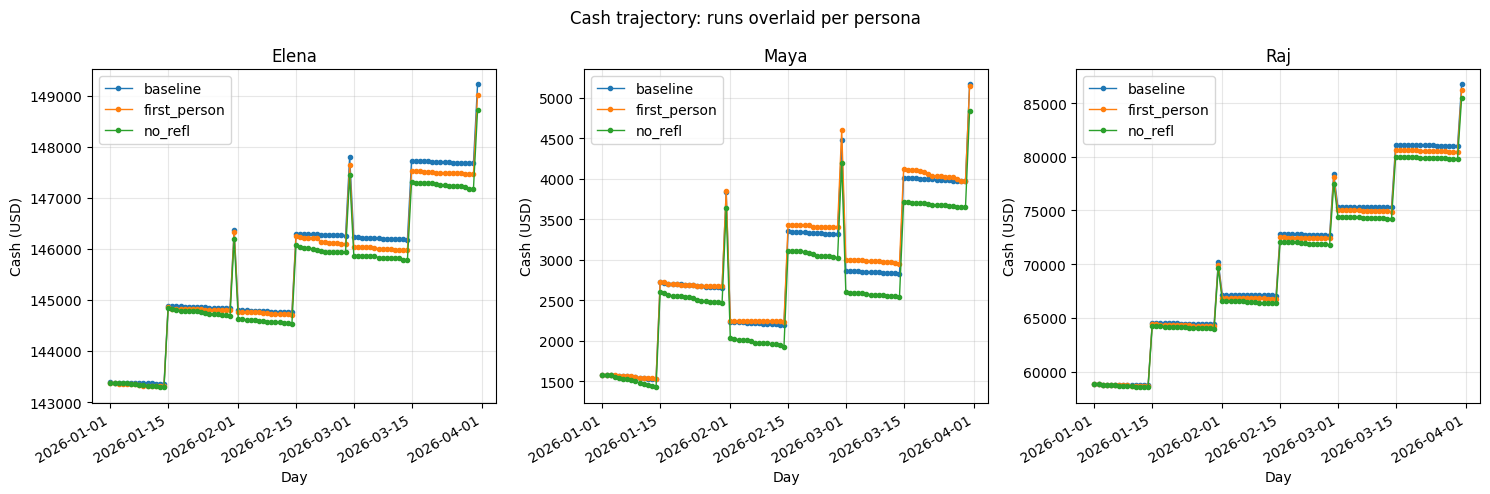

In [15]:
cash = q_all("""
  SELECT agent_id, tick_day, cash_usd FROM snapshots
  WHERE kind='daily_econ' ORDER BY agent_id, tick_day
""")

if cash.empty:
    print("No snapshot data.")
else:
    agents_in_data = sorted(cash["agent_id"].unique())
    fig, axes = plt.subplots(1, len(agents_in_data), figsize=(5 * len(agents_in_data), 5), sharey=False)
    if len(agents_in_data) == 1:
        axes = [axes]
    for ax, agent in zip(axes, agents_in_data):
        sub = cash[cash["agent_id"] == agent]
        for run_label, group in sub.groupby("run"):
            ax.plot(group["tick_day"], group["cash_usd"], marker=".", linewidth=1, label=run_label)
        ax.set_title(SHORT.get(agent, agent))
        ax.set_xlabel("Day"); ax.set_ylabel("Cash (USD)")
        ax.grid(alpha=0.3); ax.legend()
    fig.suptitle("Cash trajectory: runs overlaid per persona")
    fig.autofmt_xdate(); plt.tight_layout(); plt.show()


## 12. Behavior over time — weekly diversity & cumulative SKUs


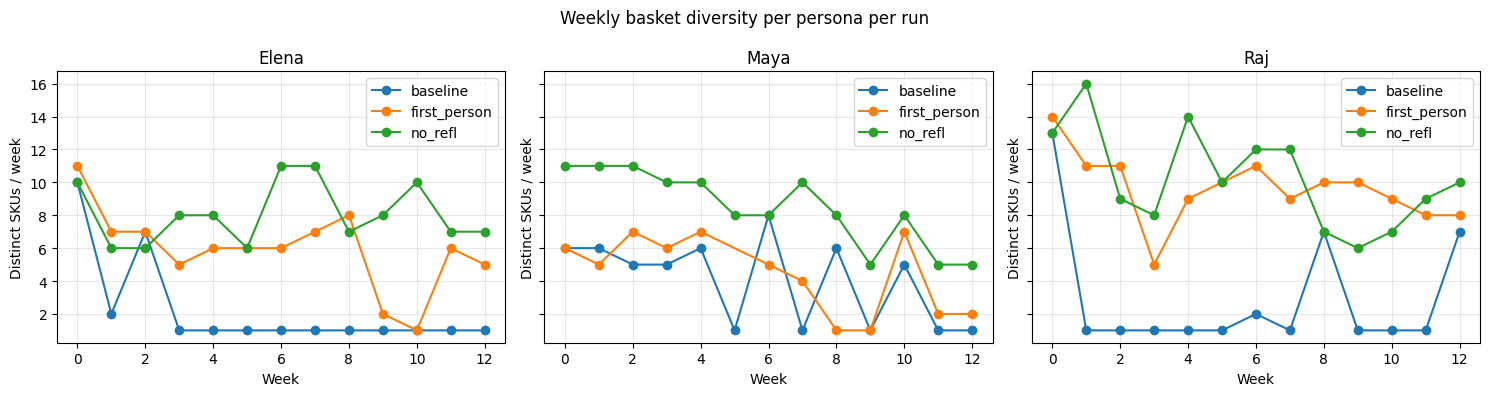

In [16]:
weekly = q_all("""
  WITH start AS (SELECT agent_id, MIN(tick_day) AS d0 FROM snapshots GROUP BY 1)
  SELECT v.agent_id,
         FLOOR((v.tick_day - s.d0) / 7.0) AS week_idx,
         COUNT(DISTINCT v.sku_id) AS distinct_skus
  FROM v_cart_add v JOIN start s USING (agent_id)
  GROUP BY 1, 2 ORDER BY 1, 2
""")

if not weekly.empty:
    agents_in_data = sorted(weekly["agent_id"].unique())
    fig, axes = plt.subplots(1, len(agents_in_data), figsize=(5 * len(agents_in_data), 4), sharey=True)
    if len(agents_in_data) == 1:
        axes = [axes]
    for ax, agent in zip(axes, agents_in_data):
        sub = weekly[weekly["agent_id"] == agent]
        for run_label, group in sub.groupby("run"):
            ax.plot(group["week_idx"], group["distinct_skus"], marker="o", label=run_label)
        ax.set_title(SHORT.get(agent, agent))
        ax.set_xlabel("Week"); ax.set_ylabel("Distinct SKUs / week")
        ax.grid(alpha=0.3); ax.legend()
    fig.suptitle("Weekly basket diversity per persona per run")
    plt.tight_layout(); plt.show()


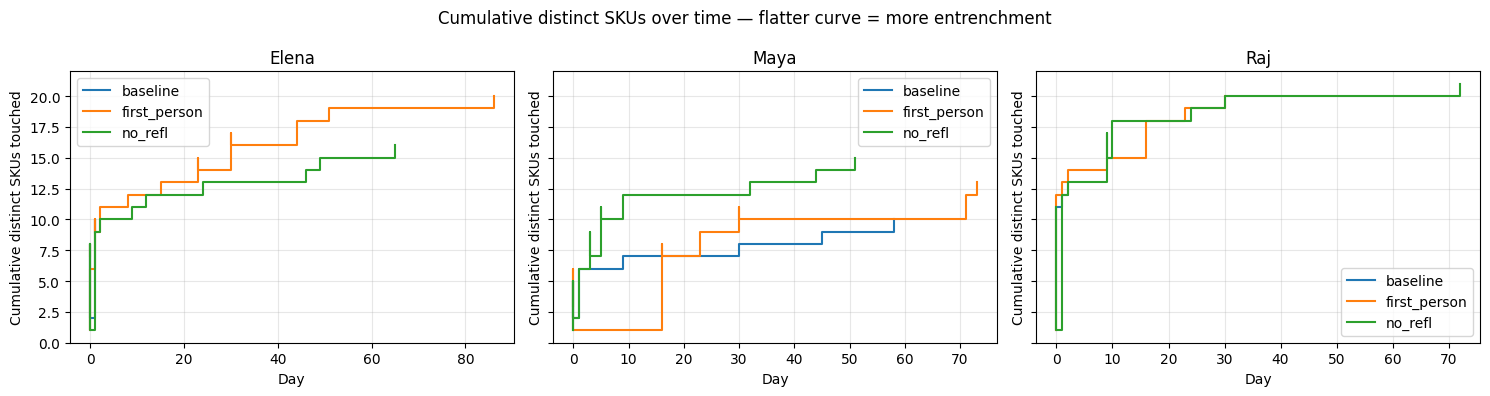

In [17]:
cum = q_all("""
  WITH start AS (SELECT agent_id, MIN(tick_day) AS d0 FROM snapshots GROUP BY 1),
  first_seen AS (SELECT v.agent_id, v.sku_id, MIN(v.tick_day) AS first_day FROM v_cart_add v GROUP BY 1, 2)
  SELECT fs.agent_id, (fs.first_day - s.d0) AS day_offset,
         ROW_NUMBER() OVER (PARTITION BY fs.agent_id ORDER BY fs.first_day) AS cumulative_distinct_skus
  FROM first_seen fs JOIN start s USING (agent_id) ORDER BY fs.agent_id, day_offset
""")

if not cum.empty:
    agents_in_data = sorted(cum["agent_id"].unique())
    fig, axes = plt.subplots(1, len(agents_in_data), figsize=(5 * len(agents_in_data), 4), sharey=True)
    if len(agents_in_data) == 1:
        axes = [axes]
    for ax, agent in zip(axes, agents_in_data):
        sub = cum[cum["agent_id"] == agent]
        for run_label, group in sub.groupby("run"):
            ax.plot(group["day_offset"], group["cumulative_distinct_skus"],
                    drawstyle="steps-post", label=run_label)
        ax.set_title(SHORT.get(agent, agent))
        ax.set_xlabel("Day"); ax.set_ylabel("Cumulative distinct SKUs touched")
        ax.grid(alpha=0.3); ax.legend()
    fig.suptitle("Cumulative distinct SKUs over time — flatter curve = more entrenchment")
    plt.tight_layout(); plt.show()


## 13. Variance and divergence


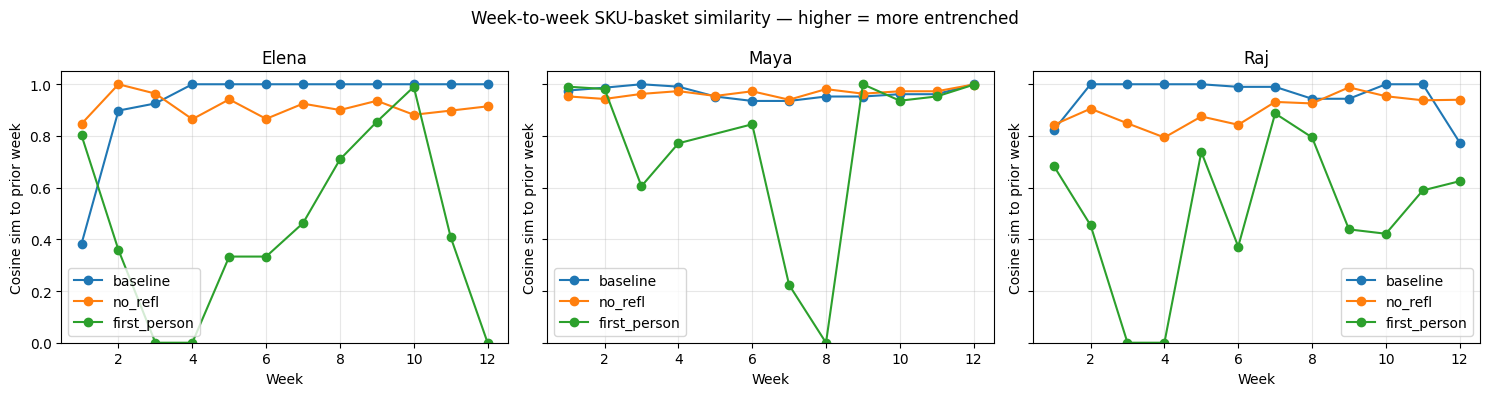

In [18]:
def _basket_vector(con, agent_id, by="category"):
    if by == "category":
        expr = ("CASE WHEN sku_id LIKE 'sku-groc-%' THEN 'groceries' "
                "WHEN sku_id LIKE 'sku-elec-%' THEN 'electronics' "
                "WHEN sku_id LIKE 'sku-dine-%' THEN 'dining' ELSE 'other' END")
    else:
        expr = "sku_id"
    df = con.execute(f"""
      WITH start AS (SELECT MIN(tick_day) AS d0 FROM snapshots WHERE agent_id='{agent_id}')
      SELECT FLOOR((tick_day - (SELECT d0 FROM start)) / 7.0) AS week_idx,
             {expr} AS bucket, COUNT(*) AS n
      FROM v_cart_add WHERE agent_id='{agent_id}'
      GROUP BY 1, 2 ORDER BY 1
    """).fetchdf()
    return df.pivot(index="week_idx", columns="bucket", values="n").fillna(0)

def cosine(a, b):
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return float("nan")
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

fig, axes = plt.subplots(1, len(AGENTS), figsize=(5 * len(AGENTS), 4), sharey=True)
if len(AGENTS) == 1:
    axes = [axes]
for ax, agent in zip(axes, AGENTS):
    for run_label, con in CONS.items():
        bv = _basket_vector(con, agent, by="sku")
        if len(bv) < 2: continue
        sims = []
        weeks = sorted(bv.index)
        for prev_w, cur_w in zip(weeks[:-1], weeks[1:]):
            sims.append((cur_w, cosine(bv.loc[prev_w].values, bv.loc[cur_w].values)))
        if sims:
            xs, ys = zip(*sims)
            ax.plot(xs, ys, marker="o", label=run_label)
    ax.set_title(SHORT[agent])
    ax.set_xlabel("Week"); ax.set_ylabel("Cosine sim to prior week")
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend()
fig.suptitle("Week-to-week SKU-basket similarity — higher = more entrenched")
plt.tight_layout(); plt.show()


In [19]:
rows = []
for run_label, con in CONS.items():
    for agent in AGENTS:
        bv = _basket_vector(con, agent, by="sku")
        if len(bv) < 2: continue
        weeks = sorted(bv.index)
        sim = cosine(bv.loc[weeks[0]].values, bv.loc[weeks[-1]].values)
        rows.append({"run": run_label, "agent": SHORT[agent],
                     "first_week": weeks[0], "last_week": weeks[-1],
                     "basket_similarity": round(sim, 3)})
wk1_vs_wkN = pd.DataFrame(rows)
print("Week-1 vs final-week SKU-basket similarity per persona per run")
print("(higher = basket barely changed; lower = persona evolved)\n")
if len(wk1_vs_wkN) > 0:
    display(wk1_vs_wkN.pivot_table(index="agent", columns="run",
                                   values="basket_similarity", aggfunc="max"))


Week-1 vs final-week SKU-basket similarity per persona per run
(higher = basket barely changed; lower = persona evolved)



run,baseline,first_person,no_refl
agent,,,
Elena,0.316,0.151,0.879
Maya,0.937,0.852,0.914
Raj,0.891,0.344,0.896


In [20]:
rows = []
for run_label, con in CONS.items():
    bvs = {agent: _basket_vector(con, agent, by="category") for agent in AGENTS}
    totals = {agent: bv.sum(axis=0) for agent, bv in bvs.items()}
    all_cats = set().union(*[t.index for t in totals.values()])
    aligned = {agent: t.reindex(sorted(all_cats), fill_value=0).values for agent, t in totals.items()}
    pairs = [("Maya", "Raj"), ("Maya", "Elena"), ("Raj", "Elena")]
    inv = {v: k for k, v in SHORT.items()}
    for (a, b) in pairs:
        if inv[a] in aligned and inv[b] in aligned:
            rows.append({"run": run_label, "pair": f"{a}↔{b}",
                         "category_basket_similarity": round(cosine(aligned[inv[a]], aligned[inv[b]]), 3)})
btwn = pd.DataFrame(rows)
print("Between-persona category-basket similarity per run")
print("(higher = personas converged to similar category mix despite different DNAs)\n")
if len(btwn) > 0:
    display(btwn.pivot_table(index="pair", columns="run",
                             values="category_basket_similarity", aggfunc="max"))


Between-persona category-basket similarity per run
(higher = personas converged to similar category mix despite different DNAs)



run,baseline,first_person,no_refl
pair,,,
Maya↔Elena,0.969,0.917,0.996
Maya↔Raj,0.987,0.687,0.996
Raj↔Elena,0.996,0.920,0.983


## 14. Reflection content — word count + settling vocabulary


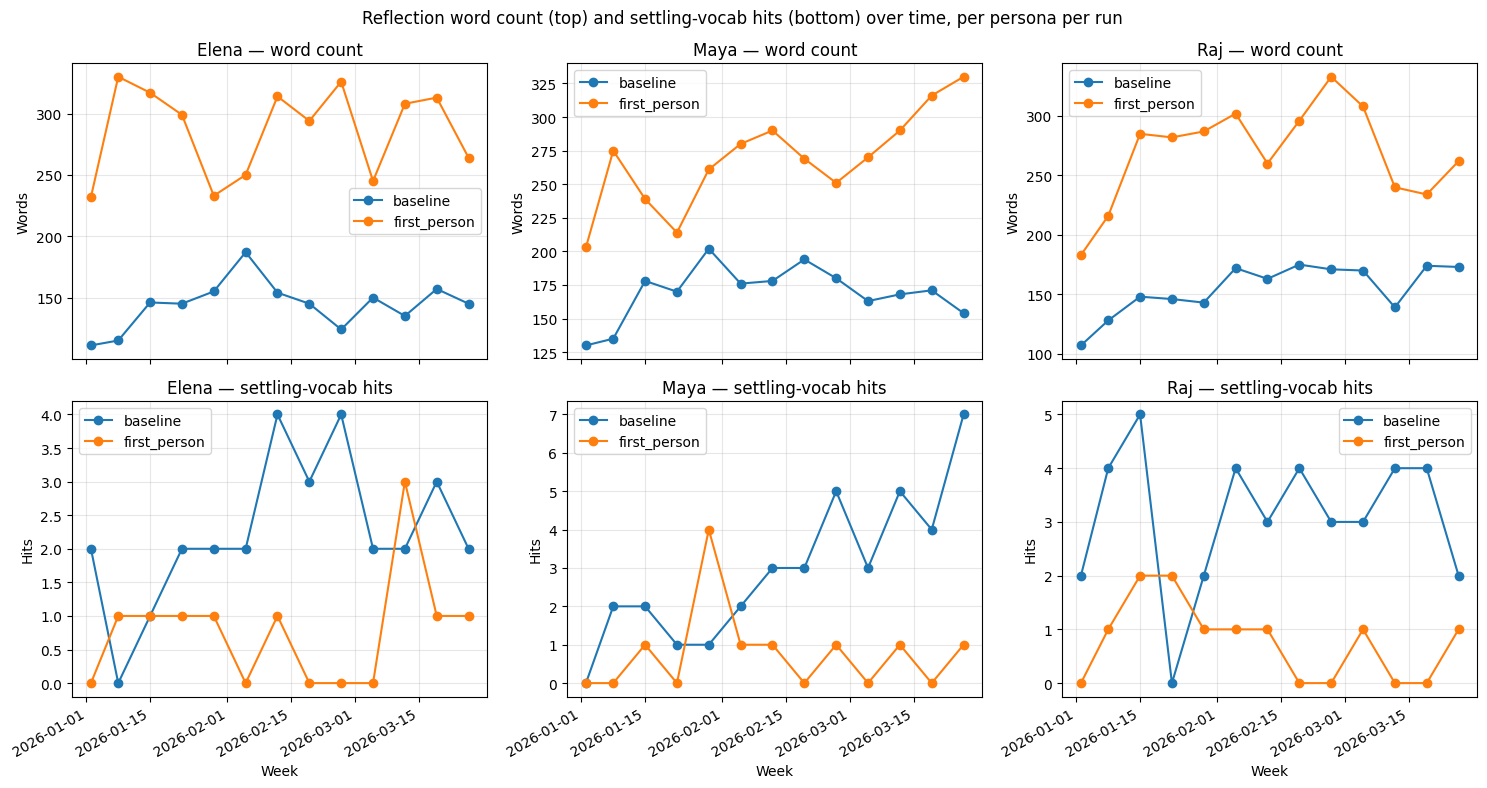

In [21]:
SETTLING_WORDS = ["habit", "habits", "habitual", "infrastructure", "automaticity",
                  "automated", "automatic", "entrenched", "entrench", "routine",
                  "routines", "fixed", "calcified", "metabolic", "streak", "loop"]

def reflection_metrics(con, agent_id):
    rows = con.execute(f"""
      SELECT tick_day, payload FROM events
      WHERE event_type='reflection' AND agent_id='{agent_id}' ORDER BY tick_day
    """).fetchall()
    out = []
    for tick_day, payload in rows:
        obs = json.loads(payload).get("observations", [])
        text = " ".join(obs).lower()
        word_count = sum(len(o.split()) for o in obs)
        settling = sum(len(re.findall(rf"\b{w}\b", text)) for w in SETTLING_WORDS)
        out.append({"tick_day": tick_day, "word_count": word_count,
                    "settling_hits": settling, "n_observations": len(obs)})
    return pd.DataFrame(out)

fig, axes = plt.subplots(2, len(AGENTS), figsize=(5 * len(AGENTS), 8))
if len(AGENTS) == 1:
    axes = axes.reshape(2, 1)
for col, agent in enumerate(AGENTS):
    for run_label, con in CONS.items():
        df = reflection_metrics(con, agent)
        if df.empty: continue
        axes[0, col].plot(df["tick_day"], df["word_count"], marker="o", label=run_label)
        axes[1, col].plot(df["tick_day"], df["settling_hits"], marker="o", label=run_label)
    axes[0, col].set_title(f"{SHORT[agent]} — word count")
    axes[1, col].set_title(f"{SHORT[agent]} — settling-vocab hits")
    axes[0, col].set_xlabel(""); axes[1, col].set_xlabel("Week")
    axes[0, col].set_ylabel("Words"); axes[1, col].set_ylabel("Hits")
    axes[0, col].grid(alpha=0.3); axes[1, col].grid(alpha=0.3)
    axes[0, col].legend(); axes[1, col].legend()
fig.autofmt_xdate()
fig.suptitle("Reflection word count (top) and settling-vocab hits (bottom) over time, per persona per run")
plt.tight_layout(); plt.show()


## 15. Reflection samples — cross-run + full reader


In [23]:
AGENT_TO_SAMPLE = "persona-maya-001"
WEEK_INDEX = 4

for run_label, con in CONS.items():
    rows = con.execute(f"""
      SELECT tick_day, payload FROM events
      WHERE event_type='reflection' AND agent_id='{AGENT_TO_SAMPLE}' ORDER BY tick_day
    """).fetchall()
    print(f"=== run: {run_label} ===")
    if not rows:
        print("  (no reflections in this run)")
    else:
        idx = min(WEEK_INDEX - 1, len(rows) - 1)
        tick_day, payload = rows[idx]
        obs = json.loads(payload).get("observations", [])
        print(f"  Week ending {tick_day}:")
        for o in obs: print(f"    - {o}")
    print()


=== run: baseline ===
  Week ending 2026-01-22:
    - Day 16 reproduces the exact structural pattern of Day 9 — a deliberate, multi-SKU grocery run (four items, $10.58) bundled into a single cart alongside the reflexive sku-dine-001 purchase — confirming that Maya's bifurcated food strategy is not a one-off anomaly but a recurring, roughly weekly cycle: six days of automated $2.98 repetition punctuated by one planned bulk-provisioning event.
    - The Day 16 grocery basket skews meaningfully cheaper per item (sku-groc-003 at $0.59, sku-groc-012 at $1.69) compared to Day 9's basket, suggesting her conscientious planning mode is not static but actively optimizing downward on unit cost across successive runs — a slow-burn price discipline layered on top of an already austere baseline.
    - Across Days 15–21, Maya's total spend was $30.52 ($17.00 in daily sku-dine-001 purchases + $13.56 on Day 16), compressing further than the prior week's $37.05 despite an identical cadence — the week-ov

In [24]:
RUN_TO_READ = "baseline"
AGENT = "persona-maya-001"
if RUN_TO_READ not in CONS:
    print(f"Run '{RUN_TO_READ}' isn't loaded.")
else:
    rows = CONS[RUN_TO_READ].execute(f"""
      SELECT tick_day, payload FROM events
      WHERE event_type='reflection' AND agent_id='{AGENT}' ORDER BY tick_day
    """).fetchall()
    if not rows: print("(no reflections)")
    else:
        for tick_day, payload in rows:
            print(f"Week ending {tick_day}:")
            for o in json.loads(payload).get("observations", []):
                print(f"  - {o}")
            print()


Week ending 2026-01-02:
  - Maya's $1,605 recurring expense on Day 0 consumed roughly two-thirds of her monthly income in a single transaction, yet her subsequent grocery and dining behavior shows hyper-deliberate, sub-$7 item selection — suggesting she operates in a post-bill 'scarcity mode' that sharply constrains her remaining discretionary choices.
  - She browsed two dining items at ret-everystore priced at $12.50 and $14.50 but ultimately purchased a $2.98 alternative at ret-valuemart, revealing a consistent cross-retailer comparison pattern where price anchoring at the budget end wins decisively over novelty or variety.
  - Her grocery basket — five distinct SKUs with no item exceeding $6.79, all added in a single efficient session with zero abandonment — reflects the conscientious, pre-planned shopping style of someone who enters with a mental list and sticks to it rather than browsing opportunistically.

Week ending 2026-01-08:
  - Despite being characterized as highly open to

## 16. Auto-summary


In [25]:
print("=" * 64)
print("REFLECTION-LOOP EXPERIMENT SUMMARY")
print("=" * 64)
print(f"Runs loaded: {list(RUNS.keys())}\n")

print("--- Top-SKU concentration (% of cart_adds for most-bought SKU) ---")
_conc = q_all("""
  WITH per_sku AS (SELECT agent_id, sku_id, COUNT(*) AS n FROM v_cart_add GROUP BY 1, 2),
  totals AS (SELECT agent_id, SUM(n) AS total FROM per_sku GROUP BY 1)
  SELECT t.agent_id, ROUND(100.0 * MAX(p.n) / t.total, 1) AS pct
  FROM per_sku p JOIN totals t USING (agent_id) GROUP BY 1, t.total
""")
print(_conc.pivot_table(index="agent_id", columns="run", values="pct", aggfunc="max", fill_value=0))
print()

print("--- Longest same-SKU consecutive-day streak ---")
_streaks = q_all("""
  WITH days AS (SELECT DISTINCT agent_id, sku_id, tick_day FROM v_cart_add),
  grouped AS (SELECT agent_id, sku_id, tick_day,
    tick_day - INTERVAL (ROW_NUMBER() OVER (PARTITION BY agent_id, sku_id ORDER BY tick_day)) DAY AS grp FROM days),
  runs AS (SELECT agent_id, sku_id, grp, COUNT(*) AS streak_len FROM grouped GROUP BY 1, 2, 3)
  SELECT agent_id, MAX(streak_len) AS longest FROM runs GROUP BY 1
""")
print(_streaks.pivot_table(index="agent_id", columns="run", values="longest", aggfunc="max", fill_value=0))
print()

print("--- Top SKU per persona per run (catalog names) ---")
_top = q_all("""
  WITH ranked AS (
    SELECT agent_id, sku_id, COUNT(DISTINCT tick_day) AS days,
           ROW_NUMBER() OVER (PARTITION BY agent_id ORDER BY COUNT(DISTINCT tick_day) DESC) AS rk
    FROM v_cart_add GROUP BY 1, 2)
  SELECT agent_id, sku_id, days FROM ranked WHERE rk = 1
""")
_top["top_sku"] = _top["sku_id"].map(lambda s: SKU_NAME.get(s, s))
print(_top.pivot_table(index="agent_id", columns="run", values="top_sku", aggfunc="first", fill_value=""))
print()

print("--- Distinct SKUs touched ---")
_div = q_all("SELECT agent_id, COUNT(DISTINCT sku_id) AS n FROM v_cart_add GROUP BY 1")
print(_div.pivot_table(index="agent_id", columns="run", values="n", aggfunc="sum", fill_value=0))
print()

print("=" * 64)
print("Interpretation guide:")
print("  - Lower concentration % across alt runs = basin loosened")
print("  - Shorter longest streak across alt runs = entrenchment reduced")
print("  - More distinct SKUs across alt runs = more exploration")
print("  - For the narrative arcs, see section 3")
print("  - For variance/divergence numbers, see section 13")
print("=" * 64)


REFLECTION-LOOP EXPERIMENT SUMMARY
Runs loaded: ['baseline', 'no_refl', 'first_person']

--- Top-SKU concentration (% of cart_adds for most-bought SKU) ---
run                baseline  first_person  no_refl
agent_id                                          
persona-elena-001      83.3          28.9     42.0
persona-maya-001       69.3          51.5     42.6
persona-raj-001        77.3          13.0     33.0

--- Longest same-SKU consecutive-day streak ---
run                baseline  first_person  no_refl
agent_id                                          
persona-elena-001        75            18       30
persona-maya-001         80            28       30
persona-raj-001          84             6       19

--- Top SKU per persona per run (catalog names) ---
run                               baseline             first_person  \
agent_id                                                              
persona-elena-001  Coffee Shop Drip Coffee  Coffee Shop Drip Coffee   
persona-maya-001   